In [2]:
from rabtracks import *

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:

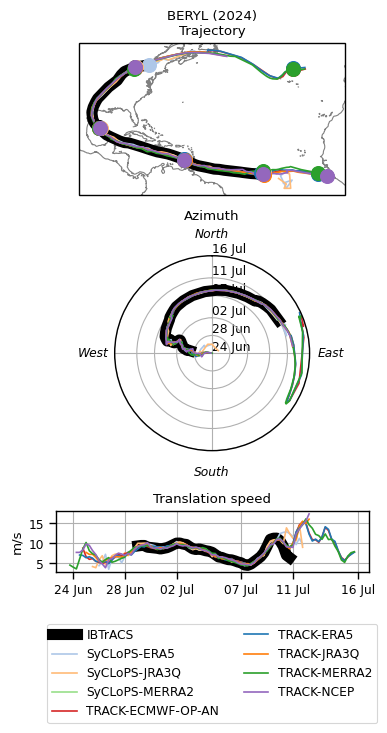

In [3]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
TRACK = eib.where((eib.name == "BERYL") & (eib.time.dt.year == 2024), drop=True)

times = ["06-24", "06-28", "07-02", "07-07", "07-11", "07-16"]
times = [np.datetime64("2024-" + t) for t in times]
t_labels = [pd.Timestamp(d).strftime("%d %b") for d in times]

sns.set_context("paper")

fig = plt.figure(figsize=cm2inch([10,17]))
# make the polar panel bigger by giving it a larger height ratio
gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 3.2, 1])

ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.Miller())
ax_map.coastlines(color="gray")
ax_map.set_title("BERYL (2024)\nTrajectory")

ax_polar = fig.add_subplot(gs[1, 0], polar=True)
ax_polar.set_theta_zero_location("N")
ax_polar.set_theta_direction(-1)
ax_polar.set_rticks(times, t_labels)
ax_polar.set_rlabel_position(0)
ax_polar.set_title("Azimuth")
ax_polar.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2], ["North", "East", "South", "West"])
for lab in ax_polar.get_xticklabels():
    lab.set_fontstyle("italic")
ax_polar.set_rlim(times[0], times[-1])

ax_bottom = fig.add_subplot(gs[2, 0])
ax_bottom.grid(axis="both")
ax_bottom.set_xticks(times, t_labels)
ax_bottom.set_title("Translation speed")
ax_bottom.set_ylabel("m/s")

for s in TRACK.source.values:
    T = TRACK.sel(source=s)
    lw = 8 if s == "IBTrACS" else None

    ax_map.plot(T.lon, T.lat, transform=ccrs.PlateCarree(), c=PALETTE[s], lw=lw, label=s)

    for t in times:
        pt = T.where(T.time == t)
        ax_map.scatter(pt.lon, pt.lat, transform=ccrs.PlateCarree(), c=PALETTE[s], s=100, zorder=100)

    ax_polar.plot(T.azimuth_roll * np.pi / 180, T.time, c=PALETTE[s], lw=lw)
    ax_bottom.plot(T.time, T.translation_speed_roll, c=PALETTE[s], lw=lw)

# leave room for legend at the bottom
plt.tight_layout(rect=[0, 0.08, 1, 1])

# bottom legend
fig.legend(
    *ax_map.get_legend_handles_labels(),
    loc="upper center",
    bbox_to_anchor=(0.55, 0.07),
    ncol=2,
    frameon=True,
)

plt.savefig("azimuth_tspeed.png", bbox_inches="tight")
plt.savefig("azimuth_tspeed.pdf", bbox_inches="tight")

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:

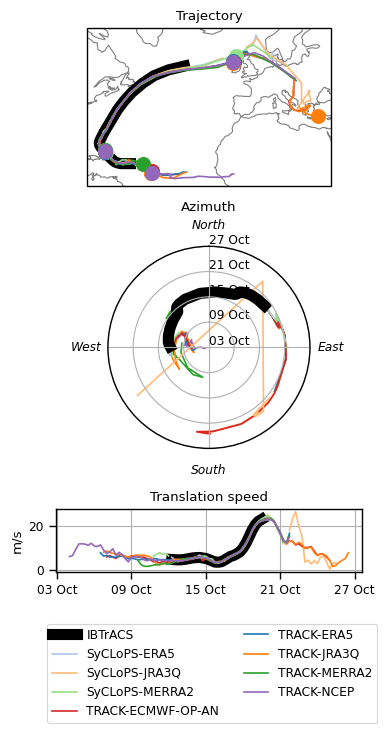

In [4]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
TRACK = eib.where((eib.name == "GONZALO") & (eib.time.dt.year == 2014), drop=True)

times = ["10-03", "10-09", "10-15", "10-21", "10-27"]
times = [np.datetime64("2014-" + t) for t in times]
t_labels = [pd.Timestamp(d).strftime("%d %b") for d in times]

fig = plt.figure(figsize=cm2inch([10,17]))
# make the polar panel bigger by giving it a larger height ratio
gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 3.2, 1])

ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.Miller())
ax_map.coastlines(color="gray")
ax_map.set_title("Trajectory")

ax_polar = fig.add_subplot(gs[1, 0], polar=True)
ax_polar.set_theta_zero_location("N")
ax_polar.set_theta_direction(-1)
ax_polar.set_rticks(times, t_labels)
ax_polar.set_rlabel_position(0)
ax_polar.set_title("Azimuth")
ax_polar.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2], ["North", "East", "South", "West"])
for lab in ax_polar.get_xticklabels():
    lab.set_fontstyle("italic")
ax_polar.set_rlim(times[0], times[-1])

ax_bottom = fig.add_subplot(gs[2, 0])
ax_bottom.grid(axis="both")
ax_bottom.set_xticks(times, t_labels)
ax_bottom.set_title("Translation speed")
ax_bottom.set_ylabel("m/s")

for i, s in enumerate(TRACK.source.values):
    T = TRACK.sel(source=s)
    lw = 8 if s == "IBTrACS" else None

    ax_map.plot(T.lon, T.lat, transform=ccrs.PlateCarree(), c=PALETTE[s], lw=lw, label=s)

    for t in times:
        pt = T.where(T.time == t)
        ax_map.scatter(pt.lon, pt.lat, transform=ccrs.PlateCarree(), c=PALETTE[s], s=100, zorder=100)

    ax_polar.plot(T.azimuth_roll[:-15] * np.pi / 180, T.time[:-15], c=PALETTE[s], lw=lw, zorder = -i)
    ax_bottom.plot(T.time, T.translation_speed_roll, c=PALETTE[s], lw=lw)

# leave room for legend at the bottom
plt.tight_layout(rect=[0, 0.08, 1, 1])

# bottom legend
fig.legend(
    *ax_map.get_legend_handles_labels(),
    loc="upper center",
    bbox_to_anchor=(0.55, 0.07),
    ncol=2,
    frameon=True,
)